In [38]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path

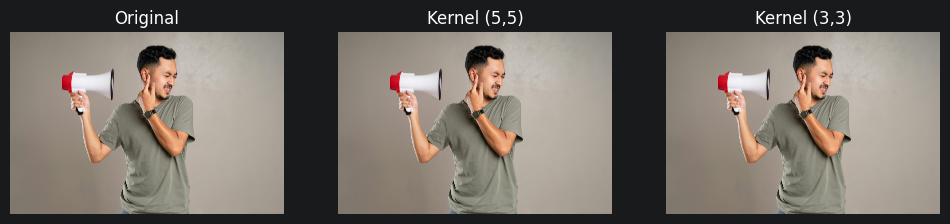

In [10]:
# Task 1
img = cv2.imread('images/test_noise_image.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# kernel (5, 5)
blur_5 = cv2.GaussianBlur(img, (5, 5), 0)

# kernel (3, 3)
blur_3 = cv2.GaussianBlur(img, (3, 3), 0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blur_5)
plt.title('Kernel (5,5)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blur_3)
plt.title('Kernel (3,3)')
plt.axis('off')

plt.show()


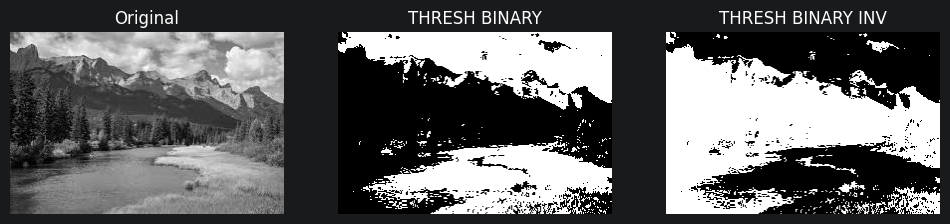

In [12]:
# Task 2
img = cv2.imread('images/test_image_2.jpeg', 0)

thresh_value = 127

_, binary = cv2.threshold(img, thresh_value, 255, cv2.THRESH_BINARY)

_, binary_inv = cv2.threshold(img, thresh_value, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title('THRESH BINARY')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(binary_inv, cmap='gray')
plt.title('THRESH BINARY INV')
plt.axis('off')

plt.show()

In [15]:
# Task 3
image_dir = "images/aug/images"
mask_dir = "images/aug/masks"

image_files = set(os.listdir(image_dir))
mask_files = set(os.listdir(mask_dir))
common_files = sorted(list(image_files & mask_files))

print(f"Total valid image-mask pairs: {len(common_files)}")

def process_batch(files):
    results = []

    for file in files:
        image_path = os.path.join(image_dir, file)
        mask_path = os.path.join(mask_dir, file)

        img = cv2.imread(image_path, 0)
        true_mask = cv2.imread(mask_path, 0)

        if img is None or true_mask is None:
            print(f"Skipped: {file}")
            continue

        if img.shape != true_mask.shape:
            print(f"Size mismatch: {file}")
            continue

        true_mask = (true_mask > 127).astype(np.uint8)

        blur = cv2.GaussianBlur(img, (3, 3), 0)
        _, pred_mask = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)
        pred_mask = (pred_mask > 127).astype(np.uint8)

        y_true = true_mask.flatten()
        y_pred = pred_mask.flatten()

        results.append({
            "image": file,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(results)

batch1_files = common_files[:10]
df1 = process_batch(batch1_files)

print("\nBatch 1 Results:")
print(df1)

if not df1.empty:
    avg1 = df1[["accuracy", "precision", "recall", "f1_score"]].mean()
    print("\nBatch 1 Average:")
    print(avg1)
else:
    print("Batch 1 has no valid data.")

batch2_files = common_files[10:20]
df2 = process_batch(batch2_files)

print("\nBatch 2 Results:")
print(df2)

if not df2.empty:
    avg2 = df2[["accuracy", "precision", "recall", "f1_score"]].mean()
    print("\nBatch 2 Average:")
    print(avg2)
else:
    print("Batch 2 has no valid data.")

if not df1.empty and not df2.empty:
    comparison = pd.DataFrame({
        "Batch 1": avg1,
        "Batch 2": avg2
    })

    print("\nComparison of Metrics:")
    print(comparison)
else:
    print("\nComparison not possible due to missing data.")

Total valid image-mask pairs: 0

Batch 1 Results:
Empty DataFrame
Columns: []
Index: []
Batch 1 has no valid data.

Batch 2 Results:
Empty DataFrame
Columns: []
Index: []
Batch 2 has no valid data.

Comparison not possible due to missing data.


Images: 552
Masks: 552


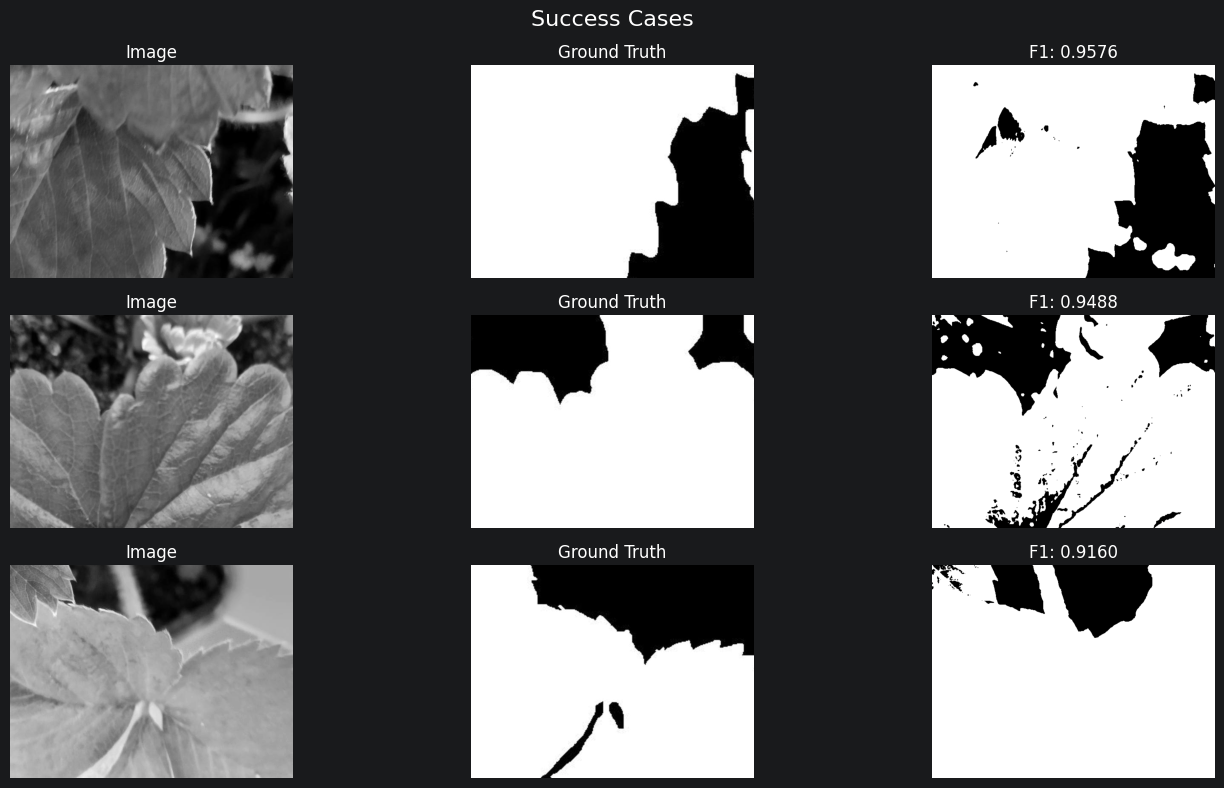

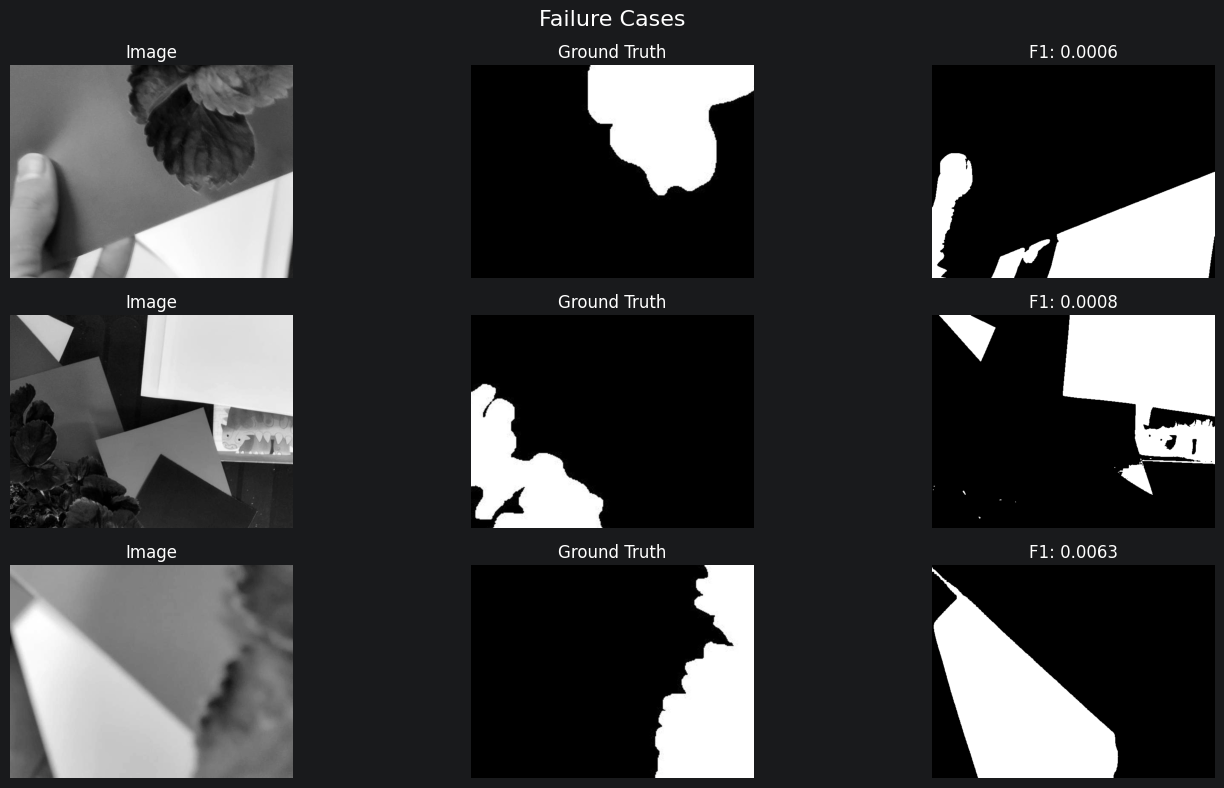

In [36]:
#Task 4
image_dir = 'images/aug/images'
mask_dir = 'images/aug/masks'

if not os.path.exists(image_dir) or not os.path.exists(mask_dir):
    print("Path is not correct")
else:
    image_files = sorted([f for f in os.listdir(image_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    mask_files = sorted([f for f in os.listdir(mask_dir)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    print("Images:", len(image_files))
    print("Masks:", len(mask_files))

    if len(image_files) != len(mask_files):
        print("WARNING: The number of image va mask are not same")

    def calculate_f1(true_mask, pred_mask):
        true_mask = (true_mask > 0).astype(np.uint8)
        pred_mask = (pred_mask > 0).astype(np.uint8)

        tp = np.sum((true_mask == 1) & (pred_mask == 1))
        fp = np.sum((true_mask == 0) & (pred_mask == 1))
        fn = np.sum((true_mask == 1) & (pred_mask == 0))

        if (2 * tp + fp + fn) == 0:
            return 1.0
        return (2 * tp) / (2 * tp + fp + fn)

    results = []

    for img_name, mask_name in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        img = cv2.imread(img_path, 0)
        true_mask = cv2.imread(mask_path, 0)

        if img is None or true_mask is None:
            print("Error reading:", img_name, mask_name)
            continue

        blur = cv2.GaussianBlur(img, (3, 3), 0)

        _, pred = cv2.threshold(blur, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        f1 = calculate_f1(true_mask, pred)

        results.append({
            "image_name": img_name,
            "mask_name": mask_name,
            "f1_score": f1
        })

    df_results = pd.DataFrame(results)

    if not df_results.empty:

        success_cases = df_results.sort_values(
            by="f1_score", ascending=False).head(3)

        failure_cases = df_results.sort_values(
            by="f1_score", ascending=True).head(3)

        def show_results(cases, title):
            plt.figure(figsize=(15, 8))
            plt.suptitle(title, fontsize=16)

            for i, row in enumerate(cases.itertuples()):
                img = cv2.imread(os.path.join(image_dir, row.image_name), 0)
                mask = cv2.imread(os.path.join(mask_dir, row.mask_name), 0)

                blur = cv2.GaussianBlur(img, (3, 3), 0)
                _, pred = cv2.threshold(blur, 0, 255,
                                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)

                plt.subplot(len(cases), 3, i*3 + 1)
                plt.imshow(img, cmap='gray')
                plt.title("Image")
                plt.axis('off')

                plt.subplot(len(cases), 3, i*3 + 2)
                plt.imshow(mask, cmap='gray')
                plt.title("Ground Truth")
                plt.axis('off')

                plt.subplot(len(cases), 3, i*3 + 3)
                plt.imshow(pred, cmap='gray')
                plt.title(f"F1: {row.f1_score:.4f}")
                plt.axis('off')

            plt.tight_layout()
            plt.show()

        show_results(success_cases, "Success Cases")
        show_results(failure_cases, "Failure Cases")

    else:
        print("Not found")

Images: 552
Masks : 552

Average IoU:
Otsu     : 0.46754814327223104
Adaptive : 0.06891457044010449


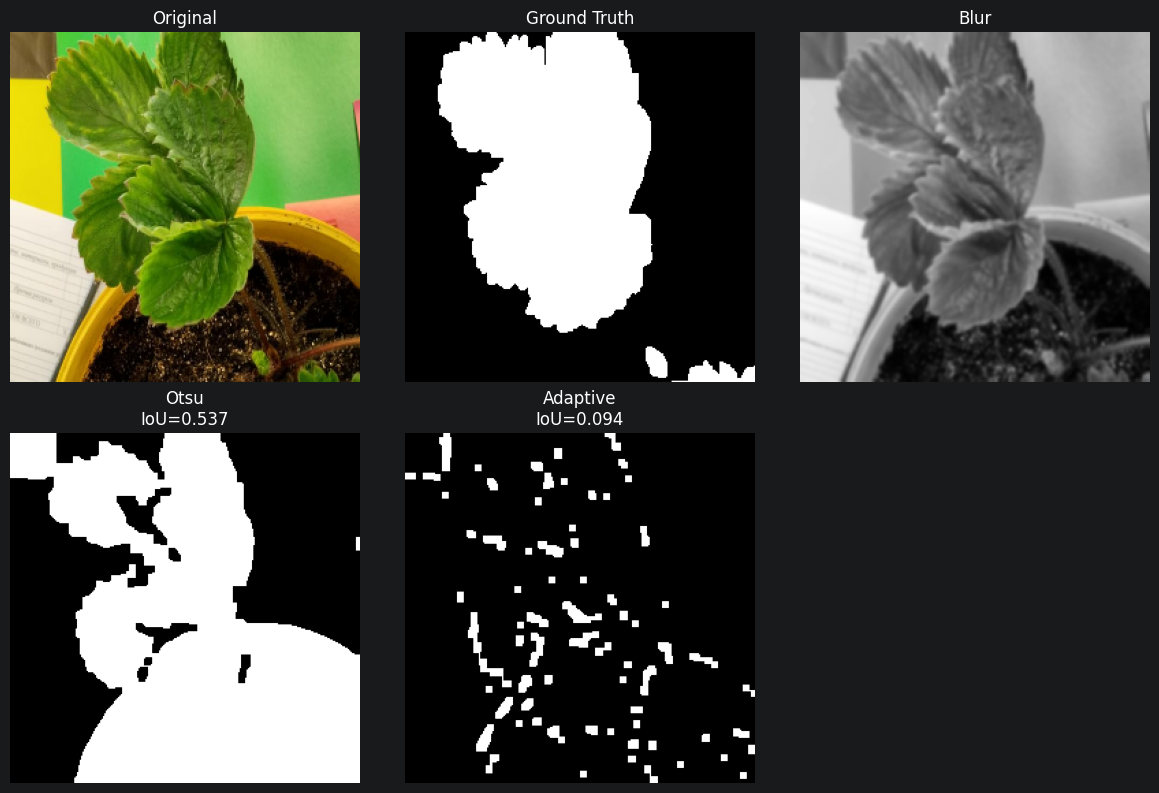

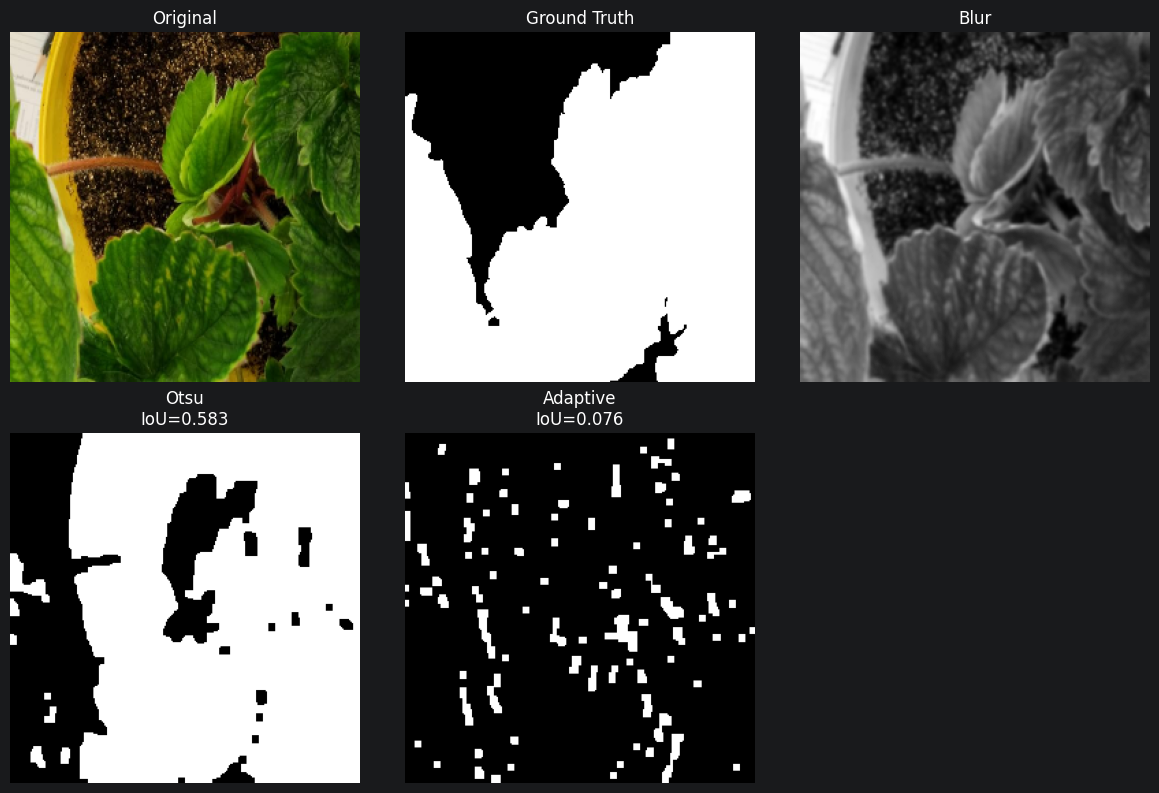

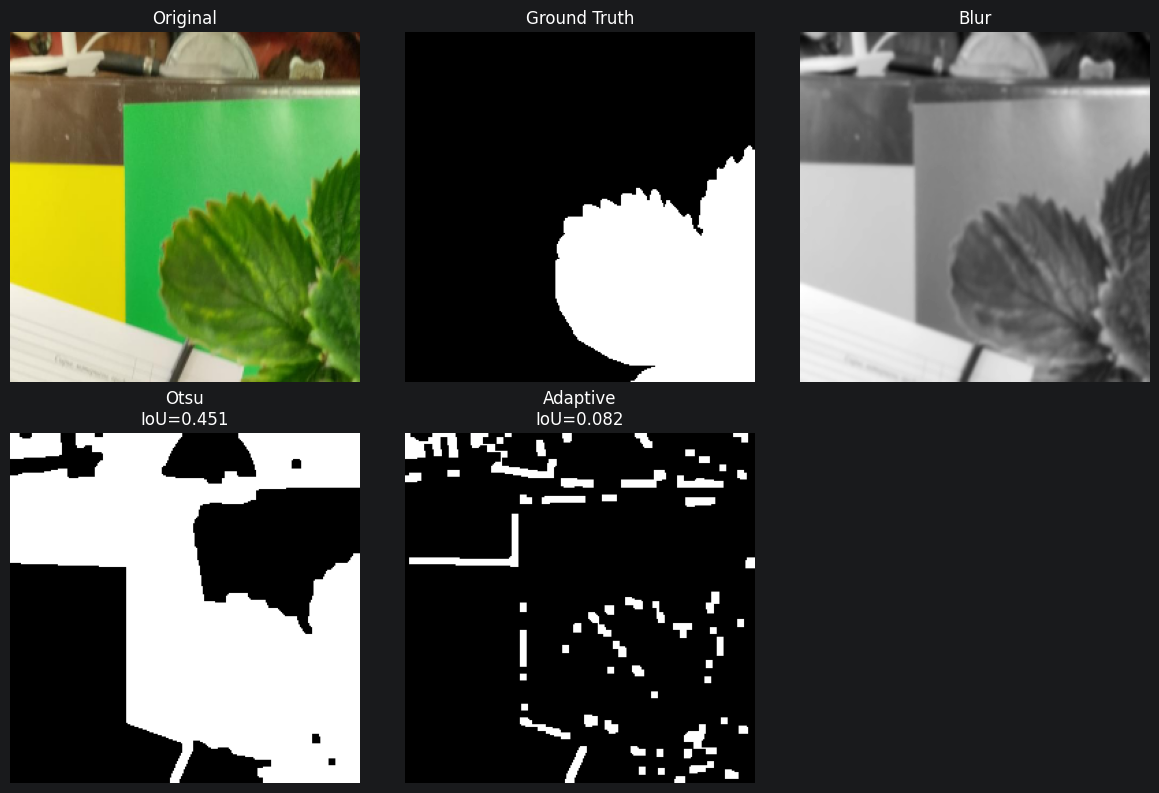

In [40]:
# Task 5
IMAGE_DIR = Path("images/aug/images")
MASK_DIR  = Path("images/aug/masks")

image_exts = {".png", ".jpg", ".jpeg", ".bmp"}

def list_files(folder):
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in image_exts])

image_files = list_files(IMAGE_DIR)
mask_files  = list_files(MASK_DIR)

print("Images:", len(image_files))
print("Masks :", len(mask_files))

pairs = list(zip(image_files, mask_files))

def read_image(path):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img

def read_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def segment(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, otsu = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    adaptive = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    kernel = np.ones((5,5), np.uint8)

    otsu = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, kernel)
    otsu = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, kernel)

    adaptive = cv2.morphologyEx(adaptive, cv2.MORPH_OPEN, kernel)
    adaptive = cv2.morphologyEx(adaptive, cv2.MORPH_CLOSE, kernel)

    return blur, otsu, adaptive

def iou(gt, pred):
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    return inter / union if union != 0 else 0

otsu_scores = []
adaptive_scores = []

for img_path, mask_path in pairs:
    img = read_image(img_path)
    gt  = read_mask(mask_path)

    blur, otsu_pred, adaptive_pred = segment(img)

    otsu_scores.append(iou(gt, otsu_pred))
    adaptive_scores.append(iou(gt, adaptive_pred))

print("\nAverage IoU:")
print("Otsu     :", np.mean(otsu_scores))
print("Adaptive :", np.mean(adaptive_scores))

for i in range(3):
    img_path, mask_path = pairs[i]

    img = read_image(img_path)
    gt  = read_mask(mask_path)

    blur, otsu_pred, adaptive_pred = segment(img)

    iou_otsu = iou(gt, otsu_pred)
    iou_adapt = iou(gt, adaptive_pred)

    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(blur, cmap="gray")
    plt.title("Blur")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(otsu_pred, cmap="gray")
    plt.title(f"Otsu\nIoU={iou_otsu:.3f}")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(adaptive_pred, cmap="gray")
    plt.title(f"Adaptive\nIoU={iou_adapt:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()